New project for trading signals and backtesting

In [25]:
#### modules
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

#stats + evaluaiton
import scipy.stats as stats
from tiingo import TiingoClient

### Look ahead bias caveat with rolling windows

In [47]:
import requests
import pandas as pd
import numpy as np
import yfinance as yf

# --------------------------------------------------
# STEP 1: Pull full SEC universe
# --------------------------------------------------
url = "https://www.sec.gov/files/company_tickers.json"
headers = {"User-Agent": "leoli@college.harvard.edu"}

response = requests.get(url, headers=headers, timeout=30)
response.raise_for_status()

raw = response.json()
tickers_df = pd.DataFrame.from_dict(raw, orient="index")
tickers_df = tickers_df.rename(columns={"cik_str": "cik", "ticker": "ticker", "title": "company_name"})
tickers_df["cik"] = tickers_df["cik"].astype(str).str.zfill(10)
tickers_df = tickers_df.dropna(subset=["ticker", "company_name"]).copy()
tickers_df["ticker"] = tickers_df["ticker"].str.upper().str.strip()
tickers_df["company_name"] = tickers_df["company_name"].str.strip()
tickers_df = tickers_df.drop_duplicates(subset=["ticker"]).reset_index(drop=True)

all_tickers = tickers_df["ticker"].tolist()
print(f"SEC universe: {len(all_tickers)} tickers")

# --------------------------------------------------
# STEP 2: Filter out obvious non-equity garbage
# Warrants (W suffix), rights (R), units (U),
# preferred (trailing letters after a dash), etc.
# --------------------------------------------------
import re

def is_clean_ticker(t):
    if len(t) > 5:
        return False
    if re.search(r'[W R U Z P Q]$', t) and len(t) > 1:
        return False
    if '-' in t or '/' in t or '.' in t:
        return False
    return True

clean_tickers = [t for t in all_tickers if is_clean_ticker(t)]
print(f"After ticker string filter: {len(clean_tickers)} tickers")

# --------------------------------------------------
# STEP 3: Batch download recent data in chunks
# yfinance chokes on huge lists; 500 at a time is safe
# --------------------------------------------------
CHUNK_SIZE = 500
all_close = []
all_volume = []

for i in range(0, len(clean_tickers), CHUNK_SIZE):
    chunk = clean_tickers[i : i + CHUNK_SIZE]
    print(f"  Downloading chunk {i//CHUNK_SIZE + 1} / {len(clean_tickers)//CHUNK_SIZE + 1} ...")
    try:
        data = yf.download(
            chunk,
            start="2023-01-01",
            end="2025-01-01",
            auto_adjust=True,
            progress=False
        )
        if data.empty:
            continue
        close = data["Close"] if isinstance(data["Close"], pd.DataFrame) else data["Close"].to_frame()
        vol   = data["Volume"] if isinstance(data["Volume"], pd.DataFrame) else data["Volume"].to_frame()
        all_close.append(close)
        all_volume.append(vol)
    except Exception as e:
        print(f"  Chunk failed: {e}")
        continue

price_raw  = pd.concat(all_close,  axis=1)
volume_raw = pd.concat(all_volume, axis=1)

# Deduplicate columns (same ticker appearing twice across chunks)
price_raw  = price_raw.loc[:, ~price_raw.columns.duplicated()]
volume_raw = volume_raw.loc[:, ~volume_raw.columns.duplicated()]

print(f"Raw downloaded universe: {price_raw.shape[1]} tickers")

# --------------------------------------------------
# STEP 4: Data quality filter
# Need at least 80% non-null close over the window
# --------------------------------------------------
min_obs = int(0.8 * len(price_raw))
quality_mask = price_raw.notna().sum(axis=0) >= min_obs
price_raw  = price_raw.loc[:, quality_mask]
volume_raw = volume_raw.loc[:, quality_mask]
print(f"After data quality filter: {price_raw.shape[1]} tickers")

# --------------------------------------------------
# STEP 5: Tradability filter (rolling, no look-ahead)
# Price >= $5 AND 20-day avg dollar vol >= $5M
# for >= 80% of trading days
# --------------------------------------------------
price_filled  = price_raw.ffill(limit=5)
volume_filled = volume_raw.reindex_like(price_filled).ffill(limit=5)

dollar_vol = price_filled * volume_filled
avg_dv     = dollar_vol.rolling(20).mean()

tradable_mask = (price_filled >= 5) & (avg_dv >= 5_000_000)
tradable_frac = tradable_mask.mean(axis=0)

tradable_tickers = tradable_frac[tradable_frac >= 0.8].index.tolist()
print(f"Tradable universe: {len(tradable_tickers)} tickers")

# --------------------------------------------------
# STEP 6: Pull full history for backtest
# --------------------------------------------------
data_full = yf.download(
    tradable_tickers,
    start="2018-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=False
)

price  = data_full["Close"].copy()
volume = data_full["Volume"].copy()

if isinstance(price,  pd.Series): price  = price.to_frame()
if isinstance(volume, pd.Series): volume = volume.to_frame()

price  = price.dropna(how="all").ffill(limit=5)
volume = volume.reindex_like(price).ffill(limit=5)

print(f"Final backtest universe: {price.shape[1]} tickers, {price.shape[0]} days")

SEC universe: 10364 tickers
After ticker string filter: 7921 tickers


$DLMAY: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1735707600")
$RSHGY: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1735707600")
$KXIAY: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1735707600")
$SNDK: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1735707600")
$CYATY: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1735707600")
$SUNB: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1735707600")
$CRWV: possibly de

$CONE: possibly delisted; no timezone found
$SOLS: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1735707600")
$ARXS: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1735707600")
$FIG: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1735707600")
$CHYM: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1735707600")
$GWKSY: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1735707600")
$ARNNY: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, 

$HNGE: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1735707600")
$IFHLY: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01)
$BLSH: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1735707600")
$OTF: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1735707600")
$SHMXY: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1735707600")
$BGSI: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1735707600")
$FLY: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't ex

$SHTPY: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1735707600")
$CHA: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1735707600")

477 Failed downloads:
['SHTPY', 'CHA']: possibly delisted; no price data found  (1d 2023-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1735707600")
['DRVN', 'SPSC', 'GDV', 'CNXN', 'VCYT', 'ELVN', 'QUBT', 'NAD', 'DRD', 'EEFT', 'DRSHF', 'VC', 'PAHC', 'STOK', 'MANE', 'EVT', 'PII', 'SNDX', 'FSM', 'MGNI', 'TGLS', 'FXCNY', 'CHEF', 'HAE', 'ROG', 'CUBI', 'SEDG', 'ATEN', 'RH', 'EYE', 'WLTH', 'DX', 'CAKE', 'NUVB', 'QLYS', 'TALO', 'EYUBY', 'DYN', 'TRMD', 'GRAL', 'OGN', 'ECO', 'SUPN', 'TTAM', 'CPRX', 'POWI', 'NHC', 'ALMS', 'GRBK', 'STC', 'INVX', 'MESO', 'NMM', 'STUB', 'BL', 'PTY', 'CCS', 'ATRO', 'BHE', 'CURLF', 'WK', 'RLAY', 'HG'

...


500 Failed downloads:
['ZGJLY', 'PLAI', 'OTAI', 'NCLA', 'EDVLY', 'FNIGY', 'CXII', 'BITB', 'SVVC', 'BSOL', 'OBNB', 'ODRS', 'DNCLY', 'GHRTF', 'CIRX', 'GRLF', 'TCRG', 'BORAY', 'BXDC', 'VNTXF', 'GSOL', 'PDSRX', 'SOLC', 'ARSTY', 'CPXXY', 'AWATY', 'DAVI', 'HNPHY', 'PDYTY', 'FXB', 'OBNK', 'RECCY', 'DETX', 'ILPLF', 'VCCG', 'SMFSY', 'TVCN', 'NNAX', 'QETH', 'IDPEY', 'TRAD', 'ALEUY', 'YGSHY', 'PBRRY', 'CNBX', 'SIGY', 'FIT', 'NATNF', 'NHLTY', 'AIMTF', 'MNTGY', 'APAT', 'AVAT', 'DSRNY', 'QRED', 'EUEV', 'SBCLY', 'ETCG', 'FSOL', 'IPSAY', 'WENC', 'IDXMF', 'NBND', 'MNZLY', 'TETH', 'SLDC', 'VROYF', 'VCRDX', 'GLIV', 'EMS', 'CMPLY', 'PLTM', 'HONA', 'APMC', 'FGO', 'NYB', 'JNGDY', 'BRUN', 'NEUT', 'ZSHLY', 'LABT', 'MTMTY', 'GFTTY', 'AIAI', 'LCDC', 'NWCYY', 'RSMIY', 'PYT', 'QVCD', 'PSBTY', 'METRY', 'CAII', 'EXYN', 'SSRLY', 'ASKRY', 'KYTFY', 'GONYF', 'JHPCY', 'RONE', 'SVIX', 'ALOG', 'UNL', 'PWRL', 'DMNT', 'YOOV', 'KERCY', 'GCAN', 'CCIL', 'OBOCY', 'NSNFY', 'OCEA', 'LPSL', 'STEK', 'DBIM', 'ETHE', 'TSUI', 'TPZEY'


491 Failed downloads:
['JATT', 'GBCS', 'MRCC', 'HLTC', 'MVCO', 'MSUXF', 'GLUC', 'CRARF', 'EBBNF', 'SNNUF', 'AIQUF', 'UA', 'EIIA', 'PPRUF', 'MRZLF', 'FMCKI', 'PTCHF', 'PTXAF', 'PUKPF', 'ANNSF', 'SWISF', 'TRLC', 'OFED', 'FALC', 'HOLX', 'ZGM', 'ENTX', 'UEPEM', 'IHRTB', 'DLAKF', 'AYASF', 'FWONK', 'DTGI', 'FNGD', 'AFGC', 'FULO', 'FNMFN', 'TSMWF', 'SBOEF', 'BMRPF', 'GOOG', 'BBDO', 'JHIUF', 'WINV', 'BHPLF', 'PTPIF', 'GRFXF', 'OSCUF', 'WEBNF', 'BCUCF', 'ATROB', 'SFDL', 'RAASY', 'GSCCF', 'AOAO', 'DGICB', 'MEOBF', 'LBRDK', 'LBTYK', 'CAJFF', 'JETBF', 'INGVF', 'HOOK', 'PELI', 'MLMC', 'KOSCF', 'CNOBF', 'POAHF', 'HMRZF', 'ATLC', 'GIFLF', 'FMCCL', 'MTTCF', 'TVC', 'GLAXF', 'MTMV', 'OXLCO', 'TROLB', 'BBVXF', 'IFNNF', 'GBNY', 'EVTK', 'GRFXY', 'ILLMF', 'DRDGF', 'RCIAF', 'HBCYF', 'SLFPF', 'FMCCI', 'RZB', 'OSBK', 'VMNT', 'BNSOF', 'FMCQF', 'UEPEN', 'NZEOF', 'SCGY', 'ERIXF', 'NSRCF', 'ASRMF', 'NXMH', 'FMCCN', 'SAPGF', 'AILLN', 'PMDI', 'MHLA', 'SNEJF', 'AEGOF', 'TKLS', 'PINXF', 'NDEKF', 'AGNCN', 'WBHC', 'LBT


498 Failed downloads:
['NZEOY', 'CCLDO', 'WHFCL', 'CHSCN', 'NICHX', 'SOJE', 'RDCT', 'UZD', 'GRTUF', 'UEPCO', 'REGCO', 'BAFBF', 'FNFPA', 'UCO', 'LAAI', 'LNWO', 'LTCFX', 'BRPSF', 'ADAMI', 'PNMXO', 'XELLL', 'ABAKF', 'UZE', 'VIXY', 'CDSG', 'CILFY', 'WTID', 'ADAML', 'SHMLF', 'ENDV', 'NEWEN', 'ZPTA', 'RWAYL', 'STNDF', 'CHSCL', 'MBINM', 'EMED', 'YCS', 'CHSCO', 'IMCI', 'SYIN', 'P', 'SAT', 'AEBMF', 'FIISO', 'CIMN', 'VERO', 'NOWGD', 'BCAEF', 'OFSSH', 'SRJN', 'PHBI', 'GAINI', 'HDLB', 'CAPT', 'ISADY', 'RILYL', 'HWLDF', 'NTRSO', 'STRF', 'GLL', 'EJTTF', 'NEMCL', 'PMBPF', 'AMLIF', 'BXDIF', 'ATLCL', 'WELPM', 'FRQN', 'MNUFF', 'EHVVF', 'GRN', 'BWNB', 'CICB', 'PCYN', 'SSHT', 'RTON', 'CORN', 'CHWRF', 'SBBTF', 'WTFCN', 'RWTN', 'ESSI', 'ATHS', 'OCCIO', 'WBKCY', 'UGL', 'IFED', 'GECCH', 'CMCLF', 'LLOBF', 'QVCC', 'HCTPF', 'BEGI', 'HBANL', 'AUIWF', 'EMRJF', 'CHSCM', 'MNUPF', 'BRLLD', 'CGABL', 'GRWTF', 'MYCB', 'FORFF', 'VLYPN', 'ADZCF', 'BPYPM', 'FRSPF', 'PRXK', 'KACLF', 'CANE', 'BRIPF', 'JJETF', 'XAKJ', 'GXXM'


415 Failed downloads:
['TCMEF', 'GGBY', 'LDXC', 'KXHCF', 'ACAT', 'SENEL', 'TOKCF', 'MSSUF', 'SLVO', 'SPGDF', 'CEHCF', 'AIMWF', 'CFLAS', 'ASAIY', 'AFGD', 'SUNFF', 'AGMWF', 'CPWPF', 'RNGOF', 'HSIGF', 'AVPKS', 'WHLRL', 'CTYFS', 'DPCDF', 'DTG', 'HPHTF', 'BLNH', 'EBBGF', 'TCLHF', 'OBIIF', 'BYCBF', 'EMCRF', 'CTFTS', 'ENFFF', 'SHFH', 'SYAXF', 'TRPEF', 'MRCIF', 'FKURF', 'AMPWF', 'EICA', 'EDVGF', 'NVAAF', 'PSBAF', 'PCPPF', 'AEHGS', 'ABXL', 'YSHLF', 'SPHXF', 'TBNRL', 'MLCMF', 'YBZN', 'ENBFF', 'MEIUF', 'HRIBF', 'ICRL', 'NTCS', 'SWCPF', 'ACQC', 'MTPLF', 'HNSDF', 'LDTDF', 'METCB', 'GGPSF', 'LKYRF', 'TPGXL', 'OXLCG', 'ASRRF', 'KCLHF', 'MGCOF', 'ZJNGF', 'WRDIF', 'AKPPS', 'JWSWF', 'WELUF', 'VDTA', 'PLMWF', 'LSHGF', 'WLGMF', 'GFRWF', 'PREJF', 'SVUWF', 'CMCWF', 'TCEYF', 'GMTH', 'LPUGF', 'CDAUF', 'RLNDF', 'GDERF', 'HNIT', 'IBIDF', 'ENNPF', 'TLPPF', 'SWZCF', 'NOFCF', 'TETWF', 'WIPKF', 'IXQUF', 'CTATF', 'IDPUF', 'GDLG', 'OPTEY', 'TNMWF', 'IMAA', 'PFSEF', 'KYFGF', 'PDPA', 'ENBNF', 'STWI', 'CSTUF', 'RPDL', 

Raw downloaded universe: 7421 tickers
After data quality filter: 1501 tickers
Tradable universe: 1194 tickers
Final backtest universe: 1194 tickers, 1761 days


Sharpe: 0.30
Total Return: 7.94%
Max Drawdown: -13.97%


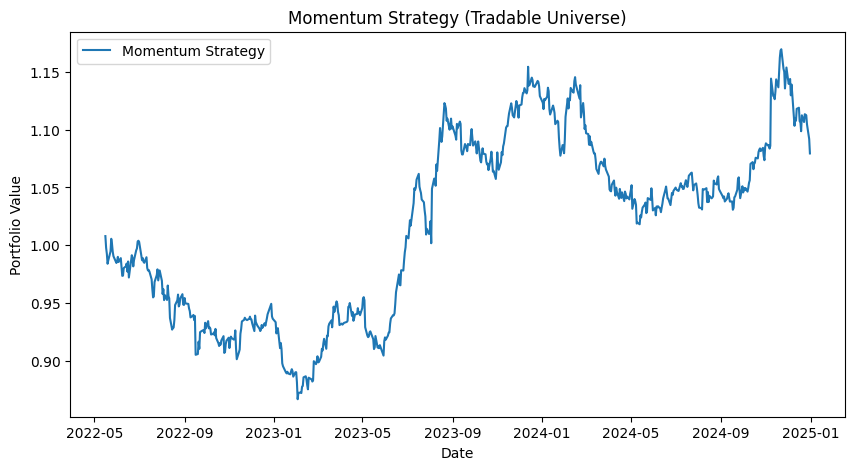

In [45]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# STEP 1: Download data using tradable tickers
# --------------------------------------------------
data = yf.download(
    tradable_tickers,
    start="2018-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=False
)

price = data["Close"].copy()

if isinstance(price, pd.Series):
    price = price.to_frame()

price = price.dropna(how="all").ffill()

# --------------------------------------------------
# STEP 2: Compute returns
# --------------------------------------------------
returns = price.pct_change().dropna()

# --------------------------------------------------
# STEP 3: Momentum signal (20-day)
# --------------------------------------------------
momentum = price.pct_change(255)

# --------------------------------------------------
# STEP 4: Rank cross-sectionally
# --------------------------------------------------
ranks = momentum.rank(axis=1, pct=True)

# --------------------------------------------------
# STEP 5: Long/Short signals
# --------------------------------------------------
long_signal = ranks > 0.8
short_signal = ranks < 0.2

# --------------------------------------------------
# STEP 6: Build weights
# --------------------------------------------------
# --------------------------------------------------
# Continuous rank-centered weights
# --------------------------------------------------
signal = ranks - 0.5

gross = signal.abs().sum(axis=1)
weights = signal.div(gross.replace(0, np.nan), axis=0)

# Lag to avoid look-ahead
weights = weights.shift(1)
weights = weights.reindex_like(returns)
# --------------------------------------------------
# STEP 7: Strategy returns
# --------------------------------------------------
strategy_returns = (weights * returns).sum(axis=1).fillna(0.0)

# --------------------------------------------------
# STEP 8: Equity curve
# --------------------------------------------------
equity_curve = (1 + strategy_returns).cumprod()

# --------------------------------------------------
# STEP 9: Metrics
# --------------------------------------------------
sharpe = strategy_returns.mean() / strategy_returns.std() * np.sqrt(252)
total_return = equity_curve.iloc[-1] - 1
max_drawdown = (equity_curve / equity_curve.cummax() - 1).min()

print(f"Sharpe: {sharpe:.2f}")
print(f"Total Return: {total_return:.2%}")
print(f"Max Drawdown: {max_drawdown:.2%}")

# --------------------------------------------------
# STEP 10: Plot
# --------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(equity_curve, label="Momentum Strategy")
plt.title("Momentum Strategy (Tradable Universe)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.show()

In [46]:
print(tradable_tickers)

['A', 'AA', 'AAAU', 'AAL', 'AAMI', 'AAOI', 'AAON', 'AAP', 'AAPL', 'AAT', 'AB', 'ABBNY', 'ABBV', 'ABCB', 'ABG', 'ABM', 'ABNB', 'ABR', 'ABT', 'ACA', 'ACAD', 'ACDC', 'ACGL', 'ACH', 'ACHC', 'ACI']
